In [164]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

df = pd.read_csv("/Users/toiizumitarou/Documents/project/day5/sample_day2.csv")
df.head()

,patient_id,age,value,date,flag
0,patient_id,age,value,date,flag
1,1,34,5.4,2024-01-01,0
2,2,58,7.1,2024-01-02,1
3,3,45,6.1,2024-01-03,0
4,4,52,7.8,2024-01-04,1


In [166]:
#型確認（念のために）
df.dtypes

patient_id    object
age           object
value         object
date          object
flag          object
dtype: object

In [168]:
# 数値への型変換
df["patient_id"] = pd.to_numeric(df["patient_id"], errors="coerce")
df["age"] = pd.to_numeric(df["age"], errors="coerce")
df["value"] = pd.to_numeric(df["value"], errors="coerce")
df["flag"] = pd.to_numeric(df["flag"], errors="coerce")

# 日付型へ変換
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# 欠損を削る（素直に全部落とす）
df = df.dropna(subset=["patient_id", "age", "value", "flag", "date"])

# 年齢層カテゴリ
df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 40, 60, 120],
    labels=["young", "middle", "senior"]
)

# high_risk フラグ
df["high_risk"] = (df["value"] > 7.5).astype(int)

df.dtypes

/var/folders/by/yd89_rh944vfysllq_zmnfyw0000gn/T/ipykernel_46040/1025533756.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["date"] = pd.to_datetime(df["date"], errors="coerce")


patient_id           float64
age                  float64
value                float64
date          datetime64[ns]
flag                 float64
age_group           category
high_risk              int64
dtype: object

In [170]:
# モデル用データフレーム（カテゴリ列はダミー変数化）
df_model = pd.get_dummies(
    df[["age", "value", "high_risk", "age_group"]],
    drop_first=True
)

X = df_model
y = df["flag"]

X.head(), y.head()

(    age  value  high_risk  age_group_middle  age_group_senior
 1  34.0    5.4          0             False             False
 2  58.0    7.1          0              True             False
 3  45.0    6.1          0              True             False
 4  52.0    7.8          1              True             False
 5  41.0    5.9          0              True             False,
 1    0.0
 2    1.0
 3    0.0
 4    1.0
 5    0.0
 Name: flag, dtype: float64)

In [172]:
#分割
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [174]:
#学習
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [176]:
#評価(accuracy&AUC)
from sklearn.metrics import accuracy_score, roc_auc_score

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print(f"Accuracy: {acc:.3f}, AUC: {auc:.3f}")

Accuracy: 0.950, AUC: 1.000


In [178]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

In [180]:
df

,patient_id,age,value,date,flag,age_group,high_risk
1,1.0,34.0,5.4,2024-01-01,0.0,young,0
2,2.0,58.0,7.1,2024-01-02,1.0,middle,0
3,3.0,45.0,6.1,2024-01-03,0.0,middle,0
4,4.0,52.0,7.8,2024-01-04,1.0,middle,1
5,5.0,41.0,5.9,2024-01-05,0.0,middle,0
...,...,...,...,...,...,...,...
96,96.0,64.0,8.4,2024-04-05,1.0,senior,1
97,97.0,28.0,4.8,2024-04-06,0.0,young,0
98,98.0,54.0,7.6,2024-04-07,1.0,middle,1
99,99.0,37.0,5.7,2024-04-08,0.0,young,0


In [182]:
# モデル用の特徴量データフレーム（ダミー変数化）
df_model = pd.get_dummies(
    df[["age", "value", "high_risk", "age_group"]],
    drop_first=True
)

X = df_model
y = df["flag"]

X.head(), y.head()

(    age  value  high_risk  age_group_middle  age_group_senior
 1  34.0    5.4          0             False             False
 2  58.0    7.1          0              True             False
 3  45.0    6.1          0              True             False
 4  52.0    7.8          1              True             False
 5  41.0    5.9          0              True             False,
 1    0.0
 2    1.0
 3    0.0
 4    1.0
 5    0.0
 Name: flag, dtype: float64)

In [184]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [186]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [188]:
from sklearn.metrics import accuracy_score, roc_auc_score

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print(f"Accuracy: {acc:.3f}, AUC: {auc:.3f}")

Accuracy: 0.950, AUC: 1.000


In [191]:
#特徴量重要度を可視化
#RandomForestがどの特徴量をどれだけ重要だと判断したかを数値で可視化して、解釈できる形にした
import pandas as pd　
　#Pythonにpandasライブラリを読み込んで、”pd”という短縮名で使えるようにする（DateFrameを作るため）
import matplotlib.pyplot as plt　
　#可視化用ライブラリの読み込み（後で特徴量重要度を棒グラフにするため）

importances = model.feature_importances_　
　#RanfomForestは多数の決定木がどの特徴をどれだけ使って判断したかを内部で記録している。その「重要度の数値」を取り出した
features = X.columns　
　#Xの列名を全て取り出している。featureに["age", "value", "high_risk", "age_group_middle", "age_group_senior"]が入る。

#featuresとimportanceをセットにするDateFrame
imp_df = pd.DataFrame({　
    "feature": features,　
    　#feature=列名
    "importance": importances　
    　#importance=それに対応する重要度
}).sort_values("importance", ascending=False)
　#重要度の高い順に並べる
　#上位３つの特徴量が、モデルの判断をほぼ決めている

imp_df
　#DateFrameを表示

,feature,importance
1,value,0.490056
0,age,0.377183
2,high_risk,0.062867
3,age_group_middle,0.049522
4,age_group_senior,0.020372


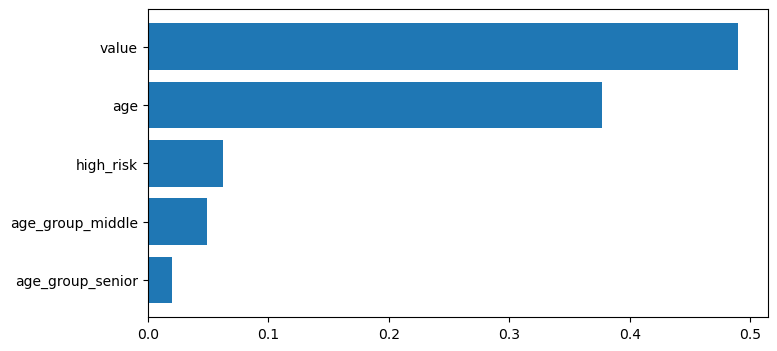

In [193]:
#特徴量を棒グラフで書く
plt.figure(figsize=(8,4))
　#８×４インチの空のキャンバスを用意する
plt.barh(imp_df["feature"], imp_df["importance"])
　#特徴量を縦軸に、重要度を横軸にした横棒グラフ（barh=horizontal bar chart）を書く
　#left(x軸)　=importance（数値）
　#yaxis(横軸)はfeatureの名前
plt.gca().invert_yaxis()
　#縦軸を逆順にする（上に重要度が高い特徴量を表示する）
　#デフォルトは下から上
plt.show()
　#図を明示

In [195]:
#混合行列(Confusion Matrix)
from sklearn.metrics import confusion_matrix
　#sckit-learnのmetrics（評価指標）から混合行列を作る関数を読み込む

cm = confusion_matrix(y_test, y_pred)
　#y_test(本当の答え)
　#y_pred(予測)
　#この2つを突き合わせてどこで当たってどこで外したかをTrue/False × Positive/Negativeで集計した行列
cm
　#結果を表示

array([[10,  0],
       [ 1,  9]])

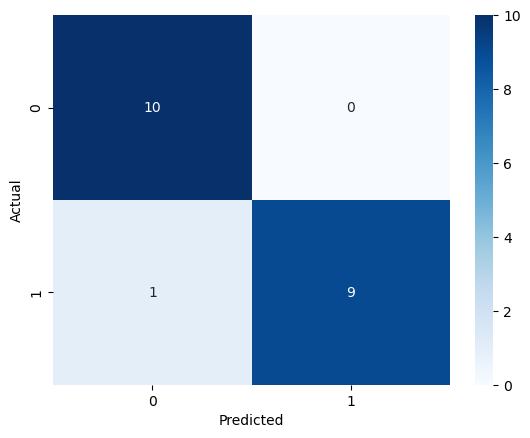

In [197]:
import seaborn as sns

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [199]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)

print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)

Precision: 1.0
Recall: 0.9
F1: 0.9473684210526315


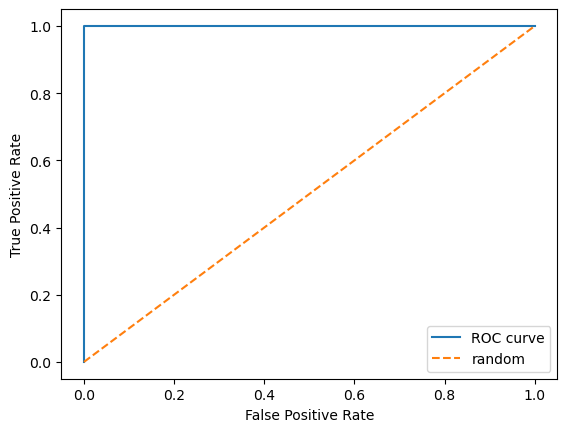

In [201]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr, label="ROC curve")
plt.plot([0, 1], [0, 1], '--', label="random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

In [203]:
threshold = 0.3
y_pred_adj = (y_prob > threshold).astype(int)

print("Recall:", recall_score(y_test, y_pred_adj))
print("Precision:", precision_score(y_test, y_pred_adj))

Recall: 1.0
Precision: 1.0
